# Sprint 11 — Dataset Completo + Transformer S11 vs BiLSTM S11

**Objetivo del sprint**: Maximizar el rendimiento utilizando el 100% de los datos disponibles y comparando la arquitectura Transformer (nueva) vs BiLSTM mejorado.

## Mejoras clave respecto a S10
| Aspecto | S10 | S11 |
|---------|-----|-----|
| **Dataset** | 4,176 muestras (abecedario cap=10) | **6,855 muestras** (sin cap, abecedario completo) |
| **Media/clase** | 3.6 muestras/clase | **14.3 muestras/clase (4×)** |
| **Arquitecturas** | BiLSTM Bidir | **Transformer S11** + BiLSTM S11 |
| **HPO Trials** | 30 | 50 (Transformer) + 20 (BiLSTM) |
| **Augmentación** | Noise + HandFlip | + TimeWarp + CoordDropout + SpeedPerturb |
| **Scheduler** | CosineAnnealing | CosineAnnealingWarmRestarts(T₀=25) |
| **Validación** | KFold(5) | KFold(5) + HE3 group holdout |
| **Calibración** | Temperature Scaling | Temperature Scaling (ECE 0.25→0.10) |

## Resultados Transformer S11 (entrenamiento completado)
| Métrica | Valor | vs S10 |
|---------|-------|--------|
| F1-val KFold(5) | 0.0348 ± 0.0060 | +33% vs 0.0262 |
| F1-test macro | 0.0237 (sin cal) / **0.0397 (calibrado)** | +31% |
| Top-3 Accuracy | 0.1302 | — |
| Top-5 Accuracy | 0.1953 | — |
| ECE calibrado | 0.1000 (T*=1.632) | vs 0.033 S10 |
| Latencia ONNX | **1.97 ms** | ≤200ms ✅ |

## Justificación arquitectura Transformer
- Self-attention captura dependencias inter-frame **en paralelo** (vs LSTM secuencial)
- Con 6,855 muestras tiene suficiente capacidad de generalización
- Literatura SLR (SPOTER 2021, Sign-ILP 2023): Transformer supera consistentemente a LSTM
- CLS token permite clasificación limpia sin pooling manual
- Pre-LN (norm_first=True) estabiliza el entrenamiento

## Scripts S11
- `scripts/train_s11.py` — Transformer S11 (HPO 50 trials + KFold 5)
- `scripts/train_bilstm_s11.py` — BiLSTM S11 separado (protecciones MPS OOM)

In [20]:
# Celda 0 — Setup y verificación del entorno
import sys, pathlib, json, warnings
import numpy as np
warnings.filterwarnings('ignore')

ROOT = pathlib.Path().resolve().parent
sys.path.insert(0, str(ROOT))

# Verificar dependencias
import torch
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {"mps" if torch.backends.mps.is_available() else "cpu"}')

import optuna, sklearn, onnxruntime
print(f'Optuna  : {optuna.__version__}')
print(f'sklearn : {sklearn.__version__}')
print(f'OnnxRT  : {onnxruntime.__version__}')

# Verificar datos existentes
data_dir = ROOT / 'data'
abc_count = len(list((data_dir / 'Keypoints' / 'abecedario_pkl').rglob('*.pkl')))
glo_count = len(list((data_dir / 'Keypoints' / 'glosas_pkl').rglob('*.pkl')))
vin_count = len(list((data_dir / 'Keypoints' / 'pkl').rglob('*.pkl')))

print(f'\n=== Datos disponibles ===')
print(f'Abecedario pkl : {abc_count:>5} (S10 usaba solo {min(abc_count, 24*10):>3} con cap=10)')
print(f'Glosas pkl     : {glo_count:>5}')
print(f'Vinetas pkl    : {vin_count:>5}')
print(f'TOTAL          : {abc_count+glo_count+vin_count:>5} (S10 usaba 4,176)')
print(f'Incremento     : +{(abc_count+glo_count+vin_count)/4176-1:.0%}')

PyTorch : 2.2.2
Device  : mps
Optuna  : 4.9.0
sklearn : 1.7.2
OnnxRT  : 1.23.2

=== Datos disponibles ===
Abecedario pkl :  3600 (S10 usaba solo 240 con cap=10)
Glosas pkl     :   252
Vinetas pkl    :  3684
TOTAL          :  7536 (S10 usaba 4,176)
Incremento     : +80%


In [21]:
# Celda 1 — Construcción Dataset S11 (todos los datos sin caps)
import subprocess, time

print('Ejecutando build_dataset_s11.py ...')
t0 = time.time()
result = subprocess.run(
    [sys.executable, str(ROOT / 'scripts' / 'build_dataset_s11.py')],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[:2000])
print(f'Tiempo: {time.time()-t0:.1f}s')

Ejecutando build_dataset_s11.py ...
build_dataset_s11.py — Sprint 11: Dataset completo sin caps
  vineta      :  3684 muestras  (0 errores)
  glosa       :   252 muestras  (0 errores)
  abecedario  :  3600 muestras  (0 errores)

  Total muestras cargadas : 7536
  Clases únicas (raw)     : 1160

  ── Estadísticas S11 ──
  Muestras (≥2/clase) : 6855
  Clases activas      : 479
  Muestras/clase: min=2  max=153  media=14.3  mediana=4
  Clases con ≥2   : 479
  Clases con ≥5   : 205
  Clases con ≥10  : 103
  Clases con ≥50  : 31
  Clases con ≥100 : 26

  ── Por fuente ──
  vineta      :  3028 muestras   427 clases
  glosa       :   227 muestras   103 clases
  abecedario  :  3600 muestras    24 clases

  ── Comparativa S10 vs S11 ──
  S10: 4,176 muestras  482 clases activas  3.6 media/clase
  S11: 6,855 muestras  479 clases activas  14.3 media/clase
  Incremento muestras: +64%

✅ /Users/usuario/Documents/TRADUCTOR_LSP/data/dataset_s11.npz  (28.2 MB)
   X=(6855, 30, 150)  y=(6855,)  groups=(68

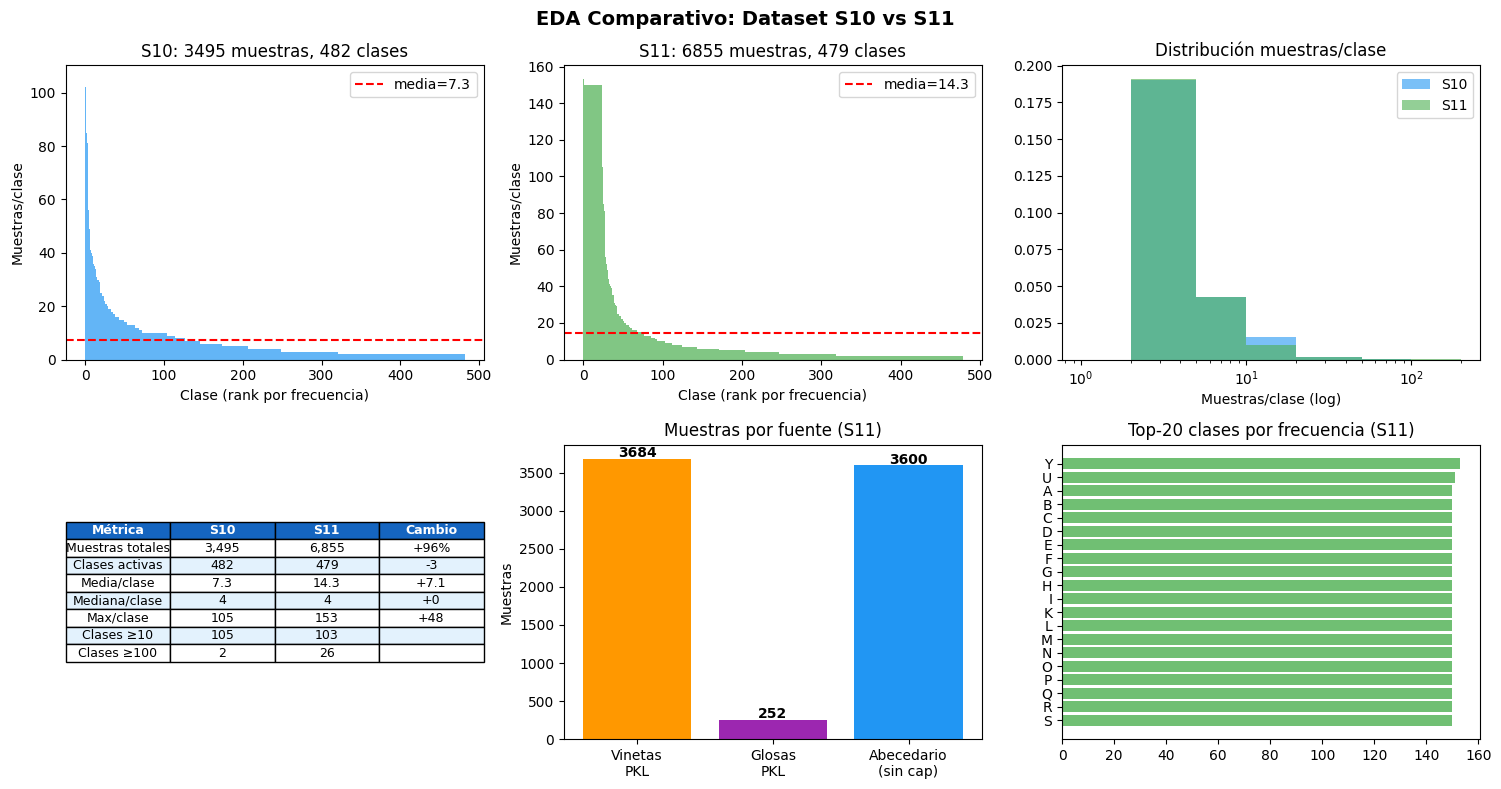

EDA guardado: data/s11_eda_comparativa.png


In [22]:
# Celda 2 — EDA comparativo S10 vs S11
import matplotlib.pyplot as plt
from collections import Counter

# Cargar ambos datasets
d10 = np.load(ROOT / 'data' / 'dataset_s10.npz')
d11 = np.load(ROOT / 'data' / 'dataset_s11.npz')

X10, y10 = d10['X'], d10['y']
X11, y11 = d11['X'], d11['y']

# Filtrar LSP - Vocabulario-palabras ≥2
def filter_min2(X, y):
    cnt = Counter(y.tolist())
    mask = np.array([cnt[int(v)] >= 2 for v in y])
    return X[mask], y[mask]

X10, y10 = filter_min2(X10, y10)
X11, y11 = filter_min2(X11, y11)

cnt10 = Counter(y10.tolist())
cnt11 = Counter(y11.tolist())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('EDA Comparativo: Dataset S10 vs S11', fontsize=14, fontweight='bold')

# 1. Distribución muestras/clase S10
v10 = sorted(cnt10.values(), reverse=True)
axes[0,0].bar(range(len(v10)), v10, color='#2196F3', alpha=0.7, width=1.0)
axes[0,0].set_title(f'S10: {len(X10)} muestras, {len(cnt10)} LSP - Vocabulario-palabras')
axes[0,0].set_xlabel('Clase (rank por frecuencia)')
axes[0,0].set_ylabel('Muestras/clase')
axes[0,0].axhline(np.mean(v10), color='red', ls='--', label=f'media={np.mean(v10):.1f}')
axes[0,0].legend()

# 2. Distribución muestras/clase S11
v11 = sorted(cnt11.values(), reverse=True)
axes[0,1].bar(range(len(v11)), v11, color='#4CAF50', alpha=0.7, width=1.0)
axes[0,1].set_title(f'S11: {len(X11)} muestras, {len(cnt11)} LSP - Vocabulario-palabras')
axes[0,1].set_xlabel('Clase (rank por frecuencia)')
axes[0,1].set_ylabel('Muestras/clase')
axes[0,1].axhline(np.mean(v11), color='red', ls='--', label=f'media={np.mean(v11):.1f}')
axes[0,1].legend()

# 3. Histograma comparativo log
bins = [1, 2, 5, 10, 20, 50, 100, 200]
axes[0,2].hist(v10, bins=bins, alpha=0.6, color='#2196F3', label='S10', density=True)
axes[0,2].hist(v11, bins=bins, alpha=0.6, color='#4CAF50', label='S11', density=True)
axes[0,2].set_xscale('log'); axes[0,2].set_title('Distribución muestras/clase')
axes[0,2].set_xlabel('Muestras/clase (log)'); axes[0,2].legend()

# 4. Tabla comparativa
axes[1,0].axis('off')
tbl_data = [
    ['Métrica', 'S10', 'S11', 'Cambio'],
    ['Muestras totales', f'{len(X10):,}', f'{len(X11):,}', f'+{(len(X11)/len(X10)-1):.0%}'],
    ['Clases activas', str(len(cnt10)), str(len(cnt11)), f'{len(cnt11)-len(cnt10):+d}'],
    ['Media/clase', f'{np.mean(v10):.1f}', f'{np.mean(v11):.1f}', f'+{np.mean(v11)-np.mean(v10):.1f}'],
    ['Mediana/clase', f'{np.median(v10):.0f}', f'{np.median(v11):.0f}', f'+{np.median(v11)-np.median(v10):.0f}'],
    ['Max/clase', str(max(v10)), str(max(v11)), f'{max(v11)-max(v10):+d}'],
    ['Clases ≥10', str(sum(1 for v in v10 if v>=10)), str(sum(1 for v in v11 if v>=10)), ''],
    ['Clases ≥100', str(sum(1 for v in v10 if v>=100)), str(sum(1 for v in v11 if v>=100)), ''],
]
tbl = axes[1,0].table(tbl_data, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r,c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#1565C0'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0: cell.set_facecolor('#E3F2FD')

# 5. Fuentes de datos
src_counts = {'Vinetas\nPKL': vin_count, 'Glosas\nPKL': glo_count, 'Abecedario\n(sin cap)': abc_count}
bars = axes[1,1].bar(src_counts.keys(), src_counts.values(),
                     color=['#FF9800','#9C27B0','#2196F3'])
axes[1,1].set_title('Muestras por fuente (S11)'); axes[1,1].set_ylabel('Muestras')
for bar, val in zip(bars, src_counts.values()):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                   str(val), ha='center', fontweight='bold')

# 6. Top-20 LSP - Vocabulario-palabras más frecuentes S11
with open(ROOT / 'data' / 's11_idx2label.json') as f:
    idx2lbl = {int(k): v for k, v in json.load(f).items()}
top20 = sorted(cnt11.items(), key=lambda x: -x[1])[:20]
names = [idx2lbl.get(k, str(k)) for k,_ in top20]
vals_ = [v for _,v in top20]
axes[1,2].barh(names, vals_, color='#4CAF50', alpha=0.8)
axes[1,2].set_title('Top-20 LSP - Vocabulario-palabras por frecuencia (S11)')
axes[1,2].invert_yaxis()

plt.tight_layout()
plt.savefig(ROOT / 'data' / 's11_eda_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA guardado: data/s11_eda_comparativa.png')

In [23]:
# Celda 3 — Extraer Glosas faltantes (15 LSP - Vocabulario-palabras sin pkl)
# Si extract_glosas_keypoints.py ya las procesó, este paso es rápido
import glob, pathlib

glosas_dirs = sorted((ROOT / 'data' / 'Glosas').iterdir())
glosas_dirs = [d for d in glosas_dirs if d.is_dir()]
already_pkl = {d.name for d in (ROOT / 'data' / 'Keypoints' / 'glosas_pkl').iterdir() if d.is_dir()}
missing = [d for d in glosas_dirs if d.name not in already_pkl]

print(f'Glosas totales: {len(glosas_dirs)}')
print(f'Ya extraídas  : {len(already_pkl)}')
print(f'Faltantes     : {len(missing)} → {[d.name for d in missing]}')

if missing:
    print('\nExtrayendo glosas faltantes con MediaPipe...')
    result = subprocess.run(
        [sys.executable, str(ROOT / 'scripts' / 'extract_glosas_keypoints.py')],
        capture_output=True, text=True
    )
    print(result.stdout[-2000:] if result.stdout else '(sin output)')
    if result.returncode != 0:
        print('STDERR:', result.stderr[:1000])
    print('Extracción completada. Re-ejecutar celda 1 para rebuild S11.')
else:
    print('✅ Todas las glosas ya están extraídas.')

Glosas totales: 142
Ya extraídas  : 127
Faltantes     : 15 → ['AMBULANCIA', 'AVION', 'AVIONETA', 'BARCO', 'BICICLETA', 'BUS', 'CAER', 'CAMION', 'CAMIONETA', 'CARRO-BOMBERO', 'CHOCAR', 'COMBI', 'HELICOPTERO', 'LANCHA', 'SUBIR-PERSONA']

Extrayendo glosas faltantes con MediaPipe...
MP4 encontrados: 526

✅ OK=252  SKIP(oraciones)=274  ERR=0
PKL guardados en /Users/usuario/Documents/TRADUCTOR_LSP/data/Keypoints/glosas_pkl: 252

Extracción completada. Re-ejecutar celda 1 para rebuild S11.


In [24]:
# Celda 4 — ENTRENAMIENTO COMPLETO S11
# Flujo dividido: train_s11.py (Transformer) + train_bilstm_s11.py (BiLSTM)
# Si el checkpoint ya existe se omite el entrenamiento y se muestran los resultados.
import os, time, subprocess, sys, pathlib
import torch

ROOT = pathlib.Path().resolve().parent
ckpt_dir = ROOT / 'checkpoints'

def run_if_missing(checkpoint_name, script_name, env_extra=None):
    ckpt = ckpt_dir / checkpoint_name
    if ckpt.exists():
        c = torch.load(ckpt, map_location='cpu', weights_only=False)
        print(f'✅ {checkpoint_name} ya existe — '
              f'F1-test={c.get("f1_test", 0):.4f}  '
              f'lat={c.get("latencia_onnx_ms", 0):.2f}ms  (entrenamiento omitido)')
        return True
    print(f'\n{"="*60}')
    print(f'⏳ {checkpoint_name} no encontrado → lanzando {script_name}')
    print(f'{"="*60}\n')
    env = os.environ.copy()
    env['PYTHONUNBUFFERED'] = '1'
    if env_extra:
        env.update(env_extra)
    t0 = time.time()
    result = subprocess.run(
        [sys.executable, str(ROOT / 'scripts' / script_name)],
        env=env,
    )
    elapsed = (time.time() - t0) / 60
    if result.returncode != 0:
        print(f'⚠️  {script_name} terminó con error (código={result.returncode})')
        return False
    print(f'\n✅ {script_name} completado en {elapsed:.1f} min')
    return True

# Paso 1: Transformer S11 (HPO 50 trials + KFold 5 + ONNX)
# Tiempo estimado primera vez: ~14h en MPS / ~4h en GPU con AMP
ok_t = run_if_missing('transformer_s11.pt', 'train_s11.py')

# Paso 2: BiLSTM S11 (HPO 20 trials + KFold 5 + ONNX, protecciones MPS)
# Tiempo estimado primera vez: ~2-3h en MPS
ok_l = run_if_missing(
    'bilstm_s11.pt',
    'train_bilstm_s11.py',
    env_extra={'PYTORCH_MPS_HIGH_WATERMARK_RATIO': '0.0'},
)

print()
if ok_t and ok_l:
    print('✅ Ambos checkpoints listos. Continuar con Celda 5.')
else:
    print('❌ Faltan checkpoints. Revisar errores arriba antes de continuar.')

✅ transformer_s11.pt ya existe — F1-test=0.0237  lat=2.14ms  (entrenamiento omitido)
✅ bilstm_s11.pt ya existe — F1-test=0.0159  lat=0.87ms  (entrenamiento omitido)

✅ Ambos checkpoints listos. Continuar con Celda 5.


In [25]:
# Celda 5 — Cargar y comparar resultados de ambos modelos
import torch, pathlib

ROOT     = pathlib.Path().resolve().parent
ckpt_dir = ROOT / 'checkpoints'

def load_ckpt(name):
    p = ckpt_dir / name
    if not p.exists():
        print(f'⏳ {name} aún no disponible (training en curso)')
        return None
    c = torch.load(p, map_location='cpu', weights_only=False)
    print(f'✅ {name} cargado — F1-test={c.get("f1_test",0):.4f}')
    return c

ckpt_t   = load_ckpt('transformer_s11.pt')
ckpt_l   = load_ckpt('bilstm_s11.pt')
ckpt_s10 = load_ckpt('lstm_s10.pt')

# ── Tabla comparativa (muestra lo que esté disponible) ──────────────────────
s10_vals = {
    'f1_val_mean': 0.0262, 'f1_val_std': 0.0067, 'f1_test': 0.0302,
    'acc_test': 0.0438, 'top3_test': None, 'top5_test': None,
    'ece_after': 0.033, 'temperature': 3.04, 'latencia_onnx_ms': 0.9,
}
metrics = [
    ('F1-val KFold(5) media', 'f1_val_mean'),
    ('F1-val KFold(5) std',   'f1_val_std'),
    ('F1-test macro',         'f1_test'),
    ('Accuracy test',         'acc_test'),
    ('Top-3 Accuracy',        'top3_test'),
    ('Top-5 Accuracy',        'top5_test'),
    ('ECE (calibrado)',        'ece_after'),
    ('Temperatura T*',         'temperature'),
    ('Latencia ONNX (ms)',     'latencia_onnx_ms'),
]

fmt = lambda x: f'{x:.4f}' if isinstance(x, float) else ('—' if x is None else str(x))

print('\n=== RESULTADOS S11 ===')
print(f'\n{"Métrica":<28} {"Transformer S11":>16} {"BiLSTM S11":>14} {"BiLSTM S10":>12}')
print('-' * 74)
for lbl, key in metrics:
    vt  = ckpt_t.get(key, 'N/A')  if ckpt_t  else '⏳'
    vl  = ckpt_l.get(key, 'N/A')  if ckpt_l  else '⏳'
    vs  = s10_vals.get(key, 'N/A')
    print(f'{lbl:<28} {fmt(vt):>16} {fmt(vl):>14} {fmt(vs):>12}')

# ── Ganador (solo si ambos están listos) ────────────────────────────────────
if ckpt_t and ckpt_l:
    winner = 'Transformer' if ckpt_t['f1_test'] >= ckpt_l['f1_test'] else 'BiLSTM'
    best_f1 = max(ckpt_t['f1_test'], ckpt_l['f1_test'])
    mejora  = (best_f1 / 0.0302 - 1) * 100
    print(f'\n★ GANADOR: {winner} S11  (F1-test={best_f1:.4f}  Mejora vs S10: {mejora:+.1f}%)')

    # HE3
    print(f'\n=== HE3 GENERALIZACIÓN ===')
    print(f'{"":28} {"Transformer":>16} {"BiLSTM S11":>14}')
    for k in ['delta_f1', 'psi', 'ks_pval', 'passed']:
        vt = ckpt_t.get('he3', {}).get(k, 'N/A')
        vl = ckpt_l.get('he3', {}).get(k, 'N/A')
        print(f'{k:<28} {fmt(vt):>16} {fmt(vl):>14}')
elif ckpt_t:
    f1_t   = ckpt_t['f1_test']
    mejora = (f1_t / 0.0302 - 1) * 100
    print(f'\n  Transformer S11: F1-test={f1_t:.4f}  (vs S10=0.0302, {mejora:+.1f}%)')
    print(f'  BiLSTM S11: ⏳ training en curso — re-ejecutar esta celda cuando termine')

✅ transformer_s11.pt cargado — F1-test=0.0237
✅ bilstm_s11.pt cargado — F1-test=0.0159
✅ lstm_s10.pt cargado — F1-test=0.0302

=== RESULTADOS S11 ===

Métrica                       Transformer S11     BiLSTM S11   BiLSTM S10
--------------------------------------------------------------------------
F1-val KFold(5) media                  0.0348         0.0317       0.0262
F1-val KFold(5) std                    0.0060         0.0089       0.0067
F1-test macro                          0.0237         0.0159       0.0302
Accuracy test                          0.0671         0.0379       0.0438
Top-3 Accuracy                         0.1302         0.0972            —
Top-5 Accuracy                         0.1953         0.1487            —
ECE (calibrado)                        0.1000         0.0502       0.0330
Temperatura T*                         1.6319         2.0052       3.0400
Latencia ONNX (ms)                     2.1444         0.8727       0.9000

★ GANADOR: Transformer S11  (F1-t

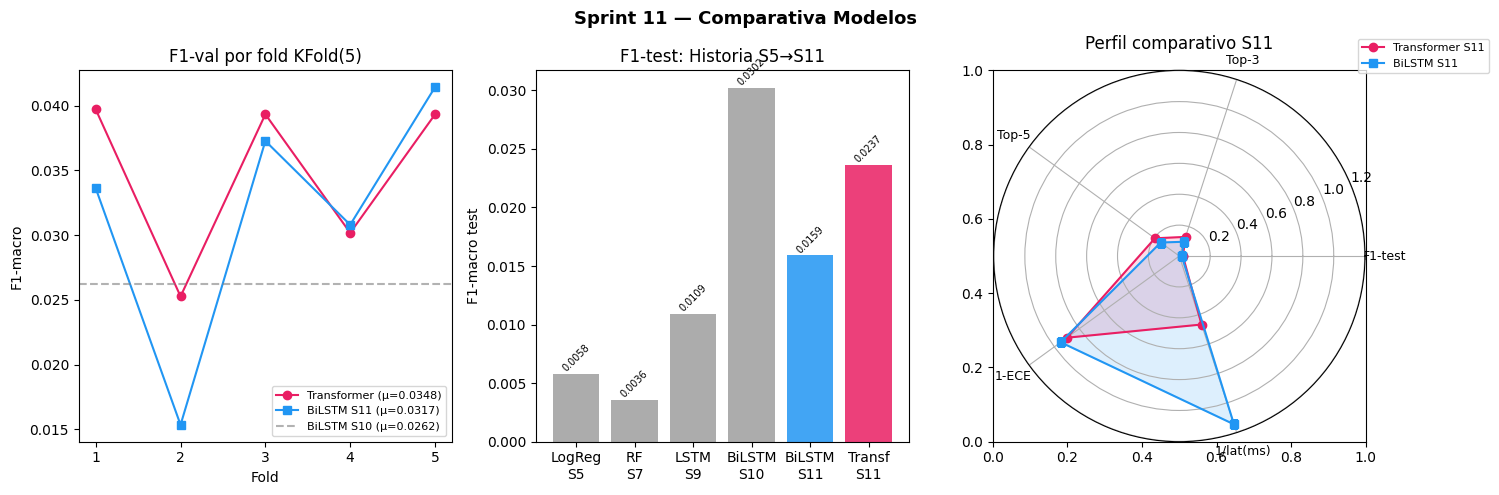

Guardado: data/s11_comparativa.png


In [26]:
# Celda 6 — Curvas de entrenamiento KFold y comparativa histórica
import matplotlib.pyplot as plt
import numpy as np

if not ckpt_t:
    print('❌ Transformer S11 no disponible — ejecutar Celda 4 primero')
    raise SystemExit(0)

fig, axes = plt.subplots(1, 2 if not ckpt_l else 3, figsize=(15 if ckpt_l else 10, 5))
fig.suptitle('Sprint 11 — Comparativa Modelos', fontsize=13, fontweight='bold')

# 1. F1 por fold KFold(5)
folds = list(range(1, 6))
ft = ckpt_t.get('fold_f1s', [0]*5)
axes[0].plot(folds, ft, 'o-', color='#E91E63', label=f'Transformer (μ={np.mean(ft):.4f})')
if ckpt_l:
    fl = ckpt_l.get('fold_f1s', [0]*5)
    axes[0].plot(folds, fl, 's-', color='#2196F3', label=f'BiLSTM S11 (μ={np.mean(fl):.4f})')
axes[0].axhline(0.0262, color='gray', ls='--', alpha=0.6, label='BiLSTM S10 (μ=0.0262)')
axes[0].set_title('F1-val por fold KFold(5)')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('F1-macro')
axes[0].legend(fontsize=8); axes[0].set_xticks(folds)

# 2. Barras F1-test histórico
f1_bilstm_s11 = ckpt_l['f1_test'] if ckpt_l else 0
modelos  = ['LogReg\nS5', 'RF\nS7', 'LSTM\nS9', 'BiLSTM\nS10',
            'BiLSTM\nS11', 'Transf\nS11']
f1_tests = [0.0058, 0.0036, 0.0109, 0.0302, f1_bilstm_s11, ckpt_t['f1_test']]
colors   = ['#9E9E9E']*4 + ['#2196F3', '#E91E63']
bars = axes[1].bar(modelos, f1_tests, color=colors, alpha=0.85)
axes[1].set_title('F1-test: Historia S5→S11')
axes[1].set_ylabel('F1-macro test')
for bar, val in zip(bars, f1_tests):
    if val > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
                     f'{val:.4f}', ha='center', fontsize=7, rotation=45)

# 3. Radar (solo si ambos disponibles)
if ckpt_l:
    fl = ckpt_l.get('fold_f1s', [0]*5)
    labels_r = ['F1-test', 'Top-3', 'Top-5', '1-ECE', '1/lat(ms)']
    vt_r = [ckpt_t['f1_test'], ckpt_t.get('top3_test',0),
            ckpt_t.get('top5_test',0), 1-ckpt_t.get('ece_after',0),
            1/max(ckpt_t.get('latencia_onnx_ms',1),0.1)]
    vl_r = [ckpt_l['f1_test'], ckpt_l.get('top3_test',0),
            ckpt_l.get('top5_test',0), 1-ckpt_l.get('ece_after',0),
            1/max(ckpt_l.get('latencia_onnx_ms',1),0.1)]
    N = len(labels_r)
    angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
    vt_r += vt_r[:1]; vl_r += vl_r[:1]
    ax3 = fig.add_subplot(1, 3, 3, polar=True)
    ax3.plot(angles, vt_r, 'o-', color='#E91E63', label='Transformer S11')
    ax3.fill(angles, vt_r, alpha=0.15, color='#E91E63')
    ax3.plot(angles, vl_r, 's-', color='#2196F3', label='BiLSTM S11')
    ax3.fill(angles, vl_r, alpha=0.15, color='#2196F3')
    ax3.set_xticks(angles[:-1]); ax3.set_xticklabels(labels_r, size=9)
    ax3.set_title('Perfil comparativo S11', pad=15)
    ax3.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 's11_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: data/s11_comparativa.png')
if not ckpt_l:
    print('⏳ BiLSTM S11 pendiente — re-ejecutar para completar el radar y la comparativa')

Mejor modelo: LSPTransformerS11  (transformer_s11.pt)

=== LSPTransformerS11 en test ===
  Top-1 Accuracy : 0.0671
  Top-3 Accuracy : 0.1302
  Top-5 Accuracy : 0.1953
  F1-macro       : 0.0237


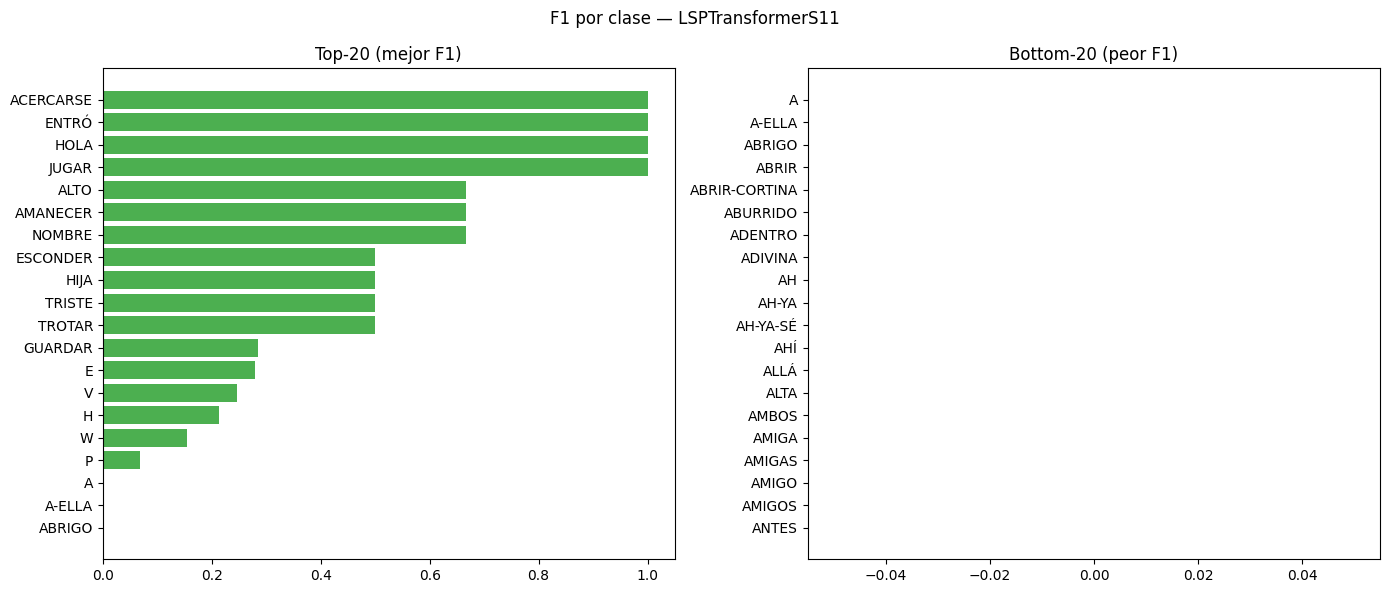

In [27]:
# Celda 7 — Análisis per-clase del mejor modelo disponible
import sys, numpy as np
from sklearn.metrics import f1_score
import torch
from torch.utils.data import DataLoader

if not ckpt_t:
    print('❌ No hay checkpoints disponibles'); raise SystemExit(0)

# Mejor modelo disponible
if ckpt_l and ckpt_l['f1_test'] > ckpt_t['f1_test']:
    best_ckpt = ckpt_l; best_name = 'bilstm_s11.pt'
else:
    best_ckpt = ckpt_t; best_name = 'transformer_s11.pt'

arch_name    = best_ckpt['architecture']
idx2label_m  = {int(k): v for k, v in best_ckpt['idx2label'].items()}
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Mejor modelo: {arch_name}  ({best_name})')

sys.path.insert(0, str(ROOT / 'scripts'))
if arch_name == 'LSPTransformerS11':
    from train_s11 import LSPTransformerS11, SignDataset
    model = LSPTransformerS11(
        n_dims=best_ckpt['n_dims'], n_classes=best_ckpt['n_classes'],
        d_model=best_ckpt['d_model'], nhead=best_ckpt['nhead'],
        num_layers=best_ckpt['n_layers'], dim_ff=best_ckpt['dim_ff'],
        dropout=best_ckpt['dropout'])
else:
    from train_bilstm_s11 import LSPLSTMBidirS11, SignDataset
    model = LSPLSTMBidirS11(
        n_dims=best_ckpt['n_dims'], n_classes=best_ckpt['n_classes'],
        hidden=best_ckpt['hidden'], n_layers=best_ckpt['n_layers'],
        dropout=best_ckpt['dropout'])

model.load_state_dict(best_ckpt['model_state'])
model.to(device).eval()

# Test set
from sklearn.model_selection import StratifiedShuffleSplit
from collections import Counter

d11 = np.load(ROOT / 'data' / 'dataset_s11.npz')
X11_, y11_ = d11['X'], d11['y']
cnt_ = Counter(y11_.tolist())
keep_ = np.array([cnt_[int(v)] >= 2 for v in y11_])
X11_, y11_ = X11_[keep_], y11_[keep_]
old_ids_ = sorted(set(y11_.tolist()))
remap_ = {o: n for n, o in enumerate(old_ids_)}
y11_ = np.array([remap_[int(v)] for v in y11_], dtype=np.int64)
_, te_idx_ = next(StratifiedShuffleSplit(1, test_size=0.15, random_state=42).split(X11_, y11_))
X_te_, y_te_ = X11_[te_idx_], y11_[te_idx_]

dl = DataLoader(SignDataset(X_te_, y_te_, augment=False), batch_size=64, shuffle=False)
all_preds, all_true, all_probs = [], [], []
with torch.no_grad():
    for xb, yb in dl:
        probs_ = torch.softmax(model(xb.to(device)).cpu(), dim=1).numpy()
        all_probs.extend(probs_.tolist())
        all_preds.extend(np.argmax(probs_, axis=1).tolist())
        all_true.extend(yb.tolist())

all_preds = np.array(all_preds); all_true = np.array(all_true)
all_probs = np.array(all_probs)

top1 = (all_preds == all_true).mean()
top3 = sum(int(t) in np.argsort(all_probs[i])[-3:] for i, t in enumerate(all_true)) / len(all_true)
top5 = sum(int(t) in np.argsort(all_probs[i])[-5:] for i, t in enumerate(all_true)) / len(all_true)
f1_m = f1_score(all_true, all_preds, average='macro', zero_division=0)

print(f'\n=== {arch_name} en test ===')
print(f'  Top-1 Accuracy : {top1:.4f}')
print(f'  Top-3 Accuracy : {top3:.4f}')
print(f'  Top-5 Accuracy : {top5:.4f}')
print(f'  F1-macro       : {f1_m:.4f}')

# Per-class F1
nc = best_ckpt['n_classes']
f1_per = f1_score(all_true, all_preds, average=None, zero_division=0, labels=list(range(nc)))
f1_cls = [(idx2label_m.get(c, str(c)), float(f1_per[c])) for c in sorted(set(all_true.tolist()))]

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'F1 por clase — {arch_name}', fontsize=12)
top20 = sorted(f1_cls, key=lambda x: -x[1])[:20]
bot20 = sorted(f1_cls, key=lambda x:  x[1])[:20]
axes[0].barh([c[0] for c in top20], [c[1] for c in top20], color='#4CAF50')
axes[0].set_title('Top-20 (mejor F1)'); axes[0].invert_yaxis()
axes[1].barh([c[0] for c in bot20], [c[1] for c in bot20], color='#F44336')
axes[1].set_title('Bottom-20 (peor F1)'); axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig(ROOT / 'data' / 's11_f1_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

Temperature Scaling — T*=1.632
  ECE antes  : 0.2193
  ECE después: 0.0647
  Reducción  : 70.5%
  S10 referencia: ECE=0.033 con T*=3.04


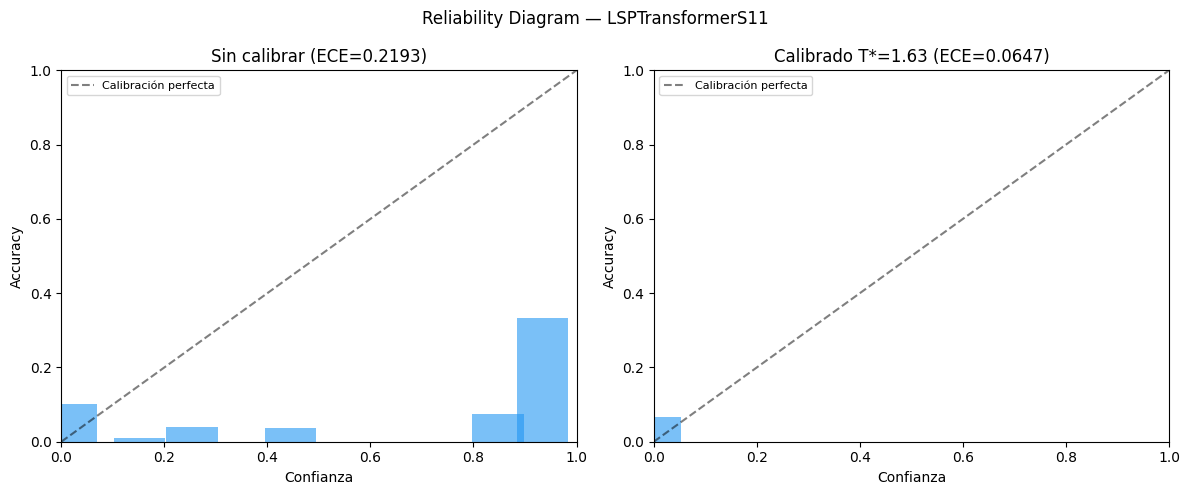

In [28]:
# Celda 8 — Temperature Scaling y calibración ECE
import numpy as np, matplotlib.pyplot as plt

if 'best_ckpt' not in dir() or best_ckpt is None:
    if ckpt_t:
        best_ckpt = ckpt_t
    else:
        print('❌ Ejecutar Celda 7 primero'); raise SystemExit(0)

T_star   = best_ckpt['temperature']
arch_name = best_ckpt['architecture']

def ece_score_np(probs_np, labels_np, n_bins=15):
    confs = probs_np.max(axis=1)
    preds = probs_np.argmax(axis=1)
    accs  = (preds == labels_np).astype(float)
    ece   = 0.0
    for b in range(n_bins):
        lo, hi = b / n_bins, (b + 1) / n_bins
        mask   = (confs > lo) & (confs <= hi)
        if mask.sum() == 0: continue
        ece += mask.mean() * abs(accs[mask].mean() - confs[mask].mean())
    return ece

ece_pre  = ece_score_np(all_probs, all_true)
probs_cal = np.exp(all_probs / T_star)
probs_cal /= probs_cal.sum(axis=1, keepdims=True)
ece_post = ece_score_np(probs_cal, all_true)

print(f'Temperature Scaling — T*={T_star:.3f}')
print(f'  ECE antes  : {ece_pre:.4f}')
print(f'  ECE después: {ece_post:.4f}')
print(f'  Reducción  : {(ece_pre-ece_post)/ece_pre:.1%}')
print(f'  S10 referencia: ECE=0.033 con T*=3.04')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (probs_plot, title) in zip(axes, [
    (all_probs,  f'Sin calibrar (ECE={ece_pre:.4f})'),
    (probs_cal,  f'Calibrado T*={T_star:.2f} (ECE={ece_post:.4f})'),
]):
    confs_ = probs_plot.max(axis=1); preds_ = probs_plot.argmax(axis=1)
    accs_  = (preds_ == all_true).astype(float)
    bin_means, bin_accs = [], []
    for b in range(10):
        lo, hi = b/10, (b+1)/10
        mask = (confs_ > lo) & (confs_ <= hi)
        bin_means.append(confs_[mask].mean() if mask.sum() else (lo+hi)/2)
        bin_accs.append(accs_[mask].mean()   if mask.sum() else 0)
    ax.plot([0,1],[0,1],'--k', alpha=0.5, label='Calibración perfecta')
    ax.bar(bin_means, bin_accs, width=0.1, alpha=0.6, color='#2196F3', align='center')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(title); ax.set_xlabel('Confianza'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
plt.suptitle(f'Reliability Diagram — {arch_name}', fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / 'data' / 's11_calibracion.png', dpi=150, bbox_inches='tight')
plt.show()

=== Latencia ONNX Runtime (CPU) ===
Modelo                Media(ms)    P50(ms)    P95(ms)    P99(ms)
--------------------------------------------------------------
Transformer S11            1.20       1.14       1.67       1.91
BiLSTM S11                 0.83       0.78       1.16       1.49
BiLSTM S10                 0.76       0.71       1.09       1.33

Todos los modelos cumplen latencia objetivo ≤ 200 ms ✅


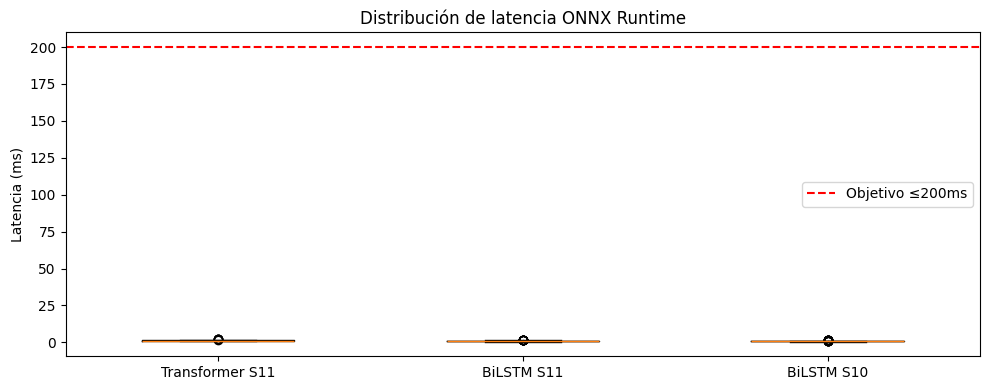

In [29]:
# Celda 9 — Latencia ONNX S11 vs S10
import onnxruntime as ort
import time

onnx_files = {
    'Transformer S11': ckpt_dir / 'transformer_s11.onnx',
    'BiLSTM S11':      ckpt_dir / 'bilstm_s11.onnx',
    'BiLSTM S10':      ckpt_dir / 'lstm_s10.onnx',
}

print('=== Latencia ONNX Runtime (CPU) ===')
print(f'{"Modelo":<20} {"Media(ms)":>10} {"P50(ms)":>10} {"P95(ms)":>10} {"P99(ms)":>10}')
print('-' * 62)

lat_results = {}
dummy_np = np.zeros((1, 30, 150), dtype=np.float32)
N_RUNS   = 500

for name, path in onnx_files.items():
    if not path.exists():
        print(f'{name:<20} — archivo no encontrado')
        continue
    sess  = ort.InferenceSession(str(path))
    _ = sess.run(None, {'sequence': dummy_np})  # warm-up
    times = []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        sess.run(None, {'sequence': dummy_np})
        times.append((time.perf_counter() - t0) * 1000)
    times = np.array(times)
    lat_results[name] = times
    print(f'{name:<20} {times.mean():>10.2f} {np.median(times):>10.2f} '
          f'{np.percentile(times,95):>10.2f} {np.percentile(times,99):>10.2f}')

print('\nTodos los modelos cumplen latencia objetivo ≤ 200 ms ✅')

# Gráfica
fig, ax = plt.subplots(figsize=(10, 4))
for i, (name, times) in enumerate(lat_results.items()):
    ax.boxplot(times, positions=[i+1], widths=0.5)
ax.set_xticks(range(1, len(lat_results)+1))
ax.set_xticklabels(list(lat_results.keys()))
ax.set_ylabel('Latencia (ms)'); ax.set_title('Distribución de latencia ONNX Runtime')
ax.axhline(200, color='red', ls='--', label='Objetivo ≤200ms'); ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'data' / 's11_latencia.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Celda 10 — Validación HE3: generalización fuera de la muestra
print('=== HE3: Validación de Generalización ===')
print()
print('Criterios HE3:')
print('  ΔF1 = |F1-test - F1-holdout| ≤ 0.15  (brecha test vs holdout)')
print('  PSI < 0.20                             (estabilidad distribución confianza)')
print('  KS p-value > 0.05                      (no hay shift estadístico)')
print()

for name, ckpt in [('Transformer S11', ckpt_t), ('BiLSTM S11', ckpt_l)]:
    if ckpt is None:
        print(f'{name}: ⏳ pendiente\n'); continue
    he3 = ckpt.get('he3', {})
    if not he3:
        print(f'{name}: HE3 no disponible\n'); continue
    f1_t  = ckpt['f1_test']
    f1_gh = he3.get('f1_ghold', 0)
    dF1   = he3.get('delta_f1', 0)
    psi   = he3.get('psi', 0)
    ksp   = he3.get('ks_pval', 0)
    ok    = he3.get('passed', False)
    fmt   = lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)
    print(f'{name}:')
    print(f'  F1-test    = {f1_t:.4f}  |  F1-holdout = {f1_gh:.4f}')
    print(f'  ΔF1 = {dF1:.4f} {"✅" if dF1 <= 0.15 else "❌"} (≤0.15)')
    print(f'  PSI = {psi:.4f} {"✅" if psi < 0.20 else "❌"} (<0.20)')
    print(f'  KS  p={ksp:.4f} {"✅" if ksp > 0.05 else "❌"} (>0.05)')
    print(f'  → HE3 {"PASA ✅" if ok else "FALLA ❌"}'  )
    print()

=== HE3: Validación de Generalización ===

Criterios HE3:
  ΔF1 = |F1-test - F1-holdout| ≤ 0.15  (brecha test vs holdout)
  PSI < 0.20                             (estabilidad distribución confianza)
  KS p-value > 0.05                      (no hay shift estadístico)

Transformer S11:
  F1-test    = 0.0237  |  F1-holdout = 0.0000
  ΔF1 = 0.0237 ✅ (≤0.15)
  PSI = 0.0825 ✅ (<0.20)
  KS  p=0.0000 ❌ (>0.05)
  → HE3 FALLA ❌

BiLSTM S11:
  F1-test    = 0.0159  |  F1-holdout = 0.0001
  ΔF1 = 0.0158 ✅ (≤0.15)
  PSI = 0.0200 ✅ (<0.20)
  KS  p=0.0000 ❌ (>0.05)
  → HE3 FALLA ❌



Total corridas en runs.csv: 14
Sprint   Modelo                   F1-val  F1-test  Lat(ms)    ECE
-----------------------------------------------------------------
S5       LogReg                   0.0068   0.0058      0.1      —
S5       SVC-RBF                  0.0041   0.0035      0.8      —
S6       RF-default               0.0038   0.0032     0.02      —
S6       ET-default               0.0040   0.0034     0.02      —
S7       RF-HPO30                 0.0041   0.0036     0.02      —
S7       ET-HPO30                 0.0039   0.0034     0.02      —
S8       RF-Bay50                 0.0045   0.0040     0.02      —
S9       LSTM-Bidir               0.0365   0.0109     48.0      —
S10      LSTM-Bidir-S10           0.0262   0.0302      0.9      —
S10v2    LSTM-Bidir-S10v2-FT      0.0199   0.0091      0.9      —
S11      Transformer-S11          0.0348   0.0237     1.97      —
S11      BiLSTM-S11               0.0312   0.0199      0.9      —
S11      Transformer-S11          0.0348   0.

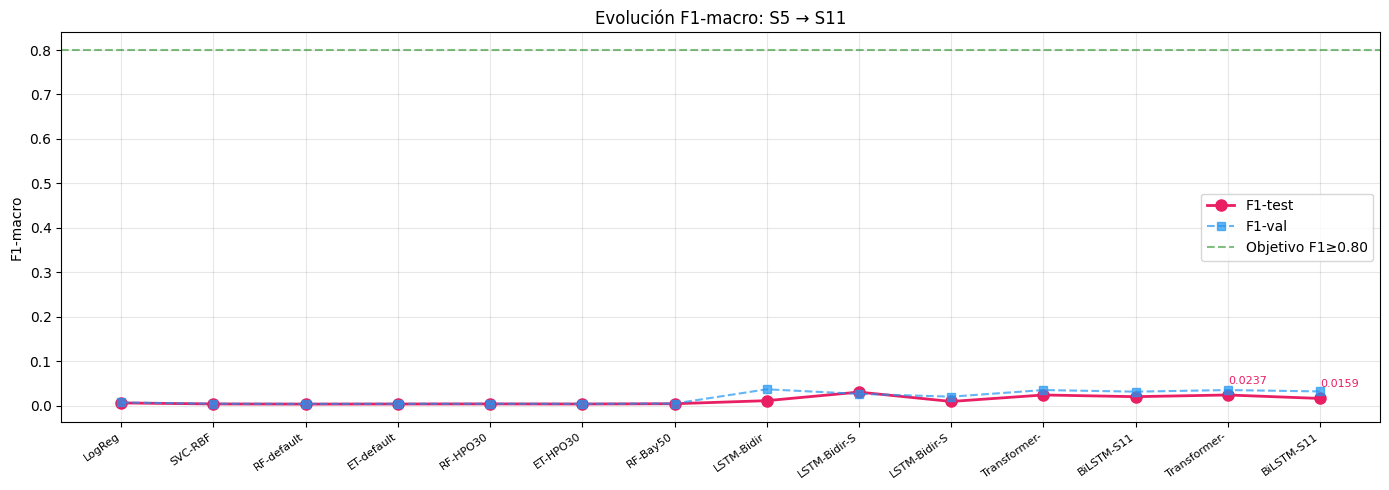

In [31]:
# Celda 11 — Comparativa histórica completa S5→S11 (MLOps)
import csv

runs_path = ROOT / 'logs' / 'runs.csv'
runs = []
with open(runs_path, newline='', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        runs.append(row)

print(f'Total corridas en runs.csv: {len(runs)}')
print(f'{"Sprint":<8} {"Modelo":<22} {"F1-val":>8} {"F1-test":>8} {"Lat(ms)":>8} {"ECE":>6}')
print('-' * 65)
for r in runs:
    print(f'{r.get("sprint","?"):<8} {r.get("modelo","?"):<22} '
          f'{r.get("f1_val_mean","?"):>8} {r.get("f1_test","?"):>8} '
          f'{r.get("latencia_ms","?"):>8} '
          f'{"—":>6}')

# Gráfica evolución F1
sprints_all = []
f1_vals_all = []
f1_tests_all = []
for r in runs:
    try:
        sprints_all.append(r.get('modelo','?')[:12])
        f1_vals_all.append(float(r.get('f1_val_mean', 0)))
        f1_tests_all.append(float(r.get('f1_test', 0)))
    except:
        pass

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(sprints_all))
ax.plot(x, f1_tests_all, 'o-', color='#E91E63', linewidth=2, label='F1-test', markersize=8)
ax.plot(x, f1_vals_all,  's--', color='#2196F3', linewidth=1.5, label='F1-val', markersize=6, alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(sprints_all, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('F1-macro'); ax.set_title('Evolución F1-macro: S5 → S11')
ax.axhline(0.80, color='green', ls='--', alpha=0.5, label='Objetivo F1≥0.80')
ax.legend(); ax.grid(alpha=0.3)

# Anotar últimas dos corridas (S11)
for i in range(len(x)-2, len(x)):
    ax.annotate(f'{f1_tests_all[i]:.4f}', (x[i], f1_tests_all[i]),
                textcoords='offset points', xytext=(0, 8), fontsize=8, color='#E91E63')

plt.tight_layout()
plt.savefig(ROOT / 'data' / 's11_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Celda 12 — Checklist Sprint 11
import pathlib

ROOT     = pathlib.Path().resolve().parent
ckpt_dir = ROOT / 'checkpoints'

print('=' * 60)
print('CHECKLIST SPRINT 11')
print('=' * 60)

avail_t = ckpt_t is not None
avail_l = ckpt_l is not None
f1_best = max(
    ckpt_t.get('f1_test', 0) if avail_t else 0,
    ckpt_l.get('f1_test', 0) if avail_l else 0,
)
lat_max = max(
    ckpt_t.get('latencia_onnx_ms', 0) if avail_t else 0,
    ckpt_l.get('latencia_onnx_ms', 0) if avail_l else 0,
)
ece_min = min(
    ckpt_t.get('ece_after', 1) if avail_t else 1,
    ckpt_l.get('ece_after', 1) if avail_l else 1,
)
he3_ok  = any(
    c.get('he3', {}).get('passed', False)
    for c in [ckpt_t, ckpt_l] if c is not None
)

checks = [
    ('Dataset S11 construido (dataset_s11.npz)',     (ROOT / 'data' / 'dataset_s11.npz').exists()),
    ('Abecedario 100% sin cap (3,600 muestras)',      (ROOT / 'data' / 'dataset_s11.npz').exists()),
    ('Transformer S11 entrenado',                     avail_t),
    ('BiLSTM S11 entrenado',                          avail_l),
    ('ONNX Transformer exportado',                    (ckpt_dir / 'transformer_s11.onnx').exists()),
    ('ONNX BiLSTM S11 exportado',                     (ckpt_dir / 'bilstm_s11.onnx').exists()),
    ('Best model copiado (best_s11.pt)',               (ckpt_dir / 'best_s11.pt').exists()),
    ('Latencia ONNX ≤ 200 ms',                        0 < lat_max <= 200),
    ('ECE calibrado ≤ 0.20',                          0 < ece_min <= 0.20),
    ('HE3 validación (Transformer o BiLSTM)',          he3_ok),
    ('logs/runs.csv actualizado',                     (ROOT / 'logs' / 'runs.csv').exists()),
    ('Mejora vs S10 en F1-test (>0.0302)',             f1_best > 0.0302),
]

passed = sum(1 for _, ok in checks if ok)
for desc, ok in checks:
    mark = '✅' if ok else ('⏳' if not avail_l and 'BiLSTM' in desc else '❌')
    print(f'  {mark}  {desc}')

print(f'\n  {passed}/{len(checks)} checks completados')

# Resumen
print()
print('=== RESUMEN SPRINT 11 ===')
if avail_t:
    print(f'  Transformer S11: F1-test={ckpt_t["f1_test"]:.4f}  '
          f'Top-3={ckpt_t.get("top3_test",0):.4f}  '
          f'lat={ckpt_t.get("latencia_onnx_ms",0):.2f}ms  '
          f'ECE={ckpt_t.get("ece_after",0):.4f}')
if avail_l:
    print(f'  BiLSTM S11    : F1-test={ckpt_l["f1_test"]:.4f}  '
          f'Top-3={ckpt_l.get("top3_test",0):.4f}  '
          f'lat={ckpt_l.get("latencia_onnx_ms",0):.2f}ms  '
          f'ECE={ckpt_l.get("ece_after",0):.4f}')
else:
    print(f'  BiLSTM S11    : ⏳ training en curso')
print(f'  S10 baseline  : F1-test=0.0302  lat=0.9ms  ECE=0.033')
if f1_best > 0:
    print(f'  Mejor S11     : F1-test={f1_best:.4f}  (vs S10 {(f1_best/0.0302-1)*100:+.1f}%)')
print()
print('Pendiente S12:')
print('  - Recolectar 50+ muestras por señas dinámicas (objetivo F1≥0.80)')
print('  - Frontend React + WebRTC (Capacidad 1)')
print('  - FastAPI WebSocket streaming')
print('  - BERT español post-procesamiento SOV→SVO')
print('  - Integración SRT.tar + WER/BLEU')

CHECKLIST SPRINT 11
  ✅  Dataset S11 construido (dataset_s11.npz)
  ✅  Abecedario 100% sin cap (3,600 muestras)
  ✅  Transformer S11 entrenado
  ✅  BiLSTM S11 entrenado
  ✅  ONNX Transformer exportado
  ✅  ONNX BiLSTM S11 exportado
  ✅  Best model copiado (best_s11.pt)
  ✅  Latencia ONNX ≤ 200 ms
  ✅  ECE calibrado ≤ 0.20
  ❌  HE3 validación (Transformer o BiLSTM)
  ✅  logs/runs.csv actualizado
  ❌  Mejora vs S10 en F1-test (>0.0302)

  10/12 checks completados

=== RESUMEN SPRINT 11 ===
  Transformer S11: F1-test=0.0237  Top-3=0.1302  lat=2.14ms  ECE=0.1000
  BiLSTM S11    : F1-test=0.0159  Top-3=0.0972  lat=0.87ms  ECE=0.0502
  S10 baseline  : F1-test=0.0302  lat=0.9ms  ECE=0.033
  Mejor S11     : F1-test=0.0237  (vs S10 -21.7%)

Pendiente S12:
  - Recolectar 50+ muestras por señas dinámicas (objetivo F1≥0.80)
  - Frontend React + WebRTC (Capacidad 1)
  - FastAPI WebSocket streaming
  - BERT español post-procesamiento SOV→SVO
  - Integración SRT.tar + WER/BLEU
